# Detecção de Objetos na Órbita Terrestre

**Para rodar com sucesso todas as célula deste notebook, recomenda-se:**

1. Criar e ativar ambiente virtual
2. Rodar ***!pip install -r requirements.txt***

## Fazendo as importações necessárias para o projeto

In [16]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import joblib
import shap

## Criando um dataframe 

Dados gerados de forma fictícia contendo características de objetos espaciais como: Lixo Espacial (0), Satélite Ativo (1) e Asteróide (2).

In [17]:
objetos_espaciais_df = pd.read_csv('../data/objetos_espaciais_complexo.csv')
objetos_espaciais_df.head(20)

,rcs_m2,albedo_optico,taxa_rotacao_rpm,variacao_termica_k,desvio_trajetoria_prevista_m,indice_espectral_metal,rugosidade_superficie,densidade_estimada_kg_m3,variacao_brilho_luz_solar,tipo_objeto
0,1.236976,0.497537,0.256004,163.130501,0.797768,0.777927,0.416255,489.328655,0.372881,0
1,0.000000,0.336466,0.000000,118.821443,0.000000,0.770810,0.639240,1695.206068,0.627565,0
2,10.805121,0.481571,0.126598,186.227868,2.326854,0.979220,0.918116,1520.614288,0.749403,0
3,0.000000,0.581564,0.000000,202.623924,10.548409,0.578488,0.744758,3302.481420,0.631209,0
4,8.079794,0.909975,34.150586,212.219711,20.706663,0.221339,0.562618,1167.815683,0.978010,0
5,14.919426,0.304312,0.212469,153.884792,16.209121,0.483901,0.380963,3018.328582,0.780744,0
6,0.000000,0.842566,14.390706,188.852294,0.000000,0.950016,0.005074,108.798599,1.001629,0
7,7.245414,0.338461,9.006136,234.772514,18.556969,0.514458,0.393333,1074.750482,0.852093,0
8,1.297227,0.471524,19.968611,61.949322,26.626093,0.863229,0.373864,2357.897819,0.035019,0
9,2.592715,0.008412,11.107976,122.658856,31.311824,0.594237,0.426467,655.389292,0.415185,0


In [18]:
x = objetos_espaciais_df.drop(columns=['tipo_objeto'], axis=1)
y = objetos_espaciais_df['tipo_objeto']


# Testando Rede Neural MLP

## Separando Dados de Treino e Teste

- Separando dados de treino e teste para prever qual o tipo de objeto

- Alocando 80% dos dados para treino e 20% para teste.

In [19]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(4000, 9) (1000, 9) (4000,) (1000,)


## Normalização dos dados com StandardScaler

In [20]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(xtrain)
x_test_scaled = scaler.transform(xtest)

## Treinamento do modelo com Rede Neural MLP

- Definidas 2 camadas ocultas contendo 100 neurônios na primeira e 56 na segunda;
- Função de ativação utilizada nas camadas ocultas: ReLU
- Número máximo de épocas:500

In [21]:
modelo_mlp = MLPClassifier(hidden_layer_sizes=(100, 56), activation='relu', max_iter=500, random_state=42)
modelo_mlp.fit(x_train_scaled, ytrain)

MLPClassifier(hidden_layer_sizes=(100, 56), max_iter=500, random_state=42)

### Acurácia do modelo MLP

Modelo alcançou 95.4% de acurácia utilizando MLP com os parâmetros definidos anteriormente.

In [22]:
y_pred = modelo_mlp.predict(x_test_scaled)
acuracia = accuracy_score(ytest, y_pred)
print(f'Acurácia do MLP: {acuracia:.4f}\n')

print(classification_report(ytest, y_pred, target_names=["Lixo Espacial", "Satélite Ativo", "Asteroide"]))

Acurácia do MLP: 0.9540

                precision    recall  f1-score   support

 Lixo Espacial       0.95      0.96      0.96       526
Satélite Ativo       0.98      0.97      0.98       167
     Asteroide       0.94      0.93      0.94       307

      accuracy                           0.95      1000
     macro avg       0.96      0.95      0.96      1000
  weighted avg       0.95      0.95      0.95      1000



### Matriz de Confusão

Podemos notar que, por mais que o desempenho geral do modelo tenha sido sólido, o segundo maior erro (22 casos) é o mais crítico para o nosso problema. Um asteroide sendo classificado como lixo pode resultar em nenhuma ação de rastreamento sendo tomada, quando na verdade o objeto merece monitormento de trajetória.

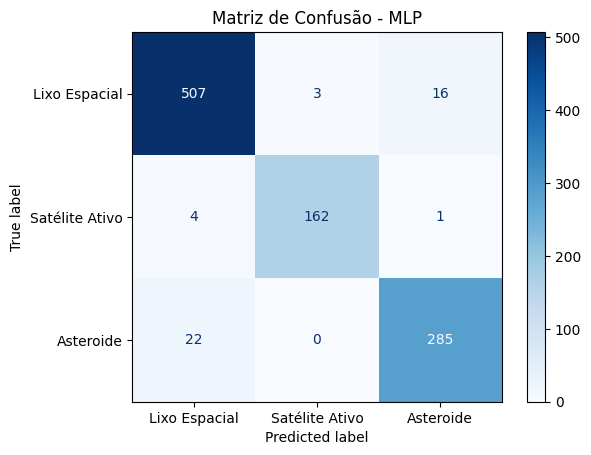

In [23]:
cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Lixo Espacial", "Satélite Ativo", "Asteroide"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - MLP")
plt.show()

# Testando XGBoost


## Separando Dados de Treino e Teste

- Separando dados de treino e teste para prever qual o tipo de objeto

- Alocando 70% dos dados para treino e 30% para teste.


In [24]:

xtrain2, xtest2, ytrain2, ytest2= train_test_split(x, y, test_size=0.3, random_state=42)

print(xtrain2.shape, xtest2.shape, ytrain2.shape, ytest2.shape)

(3500, 9) (1500, 9) (3500,) (1500,)


## Treinamento do modelo com XGBoost

Utilizando modelo XGBoost para classificação

Foram definidas 502 árvores de decisão com profundidade máxima de 4 e taxa de aprendizado de 0.1

In [25]:
modelo_xgb = XGBClassifier(n_estimators=502, max_depth=4, learning_rate=0.1, random_state=42)
modelo_xgb.fit(xtrain2, ytrain2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=502, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

### Acurácia do Modelo

Foi alcançada uma acurácia de 96.4% do modelo utilizando XGBoost com os parâmetros definidos anteriormente.

In [26]:
ypred_train = modelo_xgb.predict(xtrain2)
ypred_test = modelo_xgb.predict(xtest2)

acuracia_treino = accuracy_score(ytrain2, ypred_train)
acuracia_teste = accuracy_score(ytest2, ypred_test)

print(f'Acurácia no conjunto de teste: {acuracia_teste:.4f}')

Acurácia no conjunto de teste: 0.9640


## Feature Importance

Utilizando feature importance parar mostrar o quanto cada variável influencia na previsão do modelo

In [27]:
importancias = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importância': modelo_xgb.feature_importances_
}).sort_values(by='Importância', ascending=False)

print(importancias)

                        Feature  Importância
5        indice_espectral_metal     0.216553
6         rugosidade_superficie     0.180820
2              taxa_rotacao_rpm     0.173813
8     variacao_brilho_luz_solar     0.154137
4  desvio_trajetoria_prevista_m     0.112827
0                        rcs_m2     0.071402
1                 albedo_optico     0.041688
3            variacao_termica_k     0.031375
7      densidade_estimada_kg_m3     0.017384


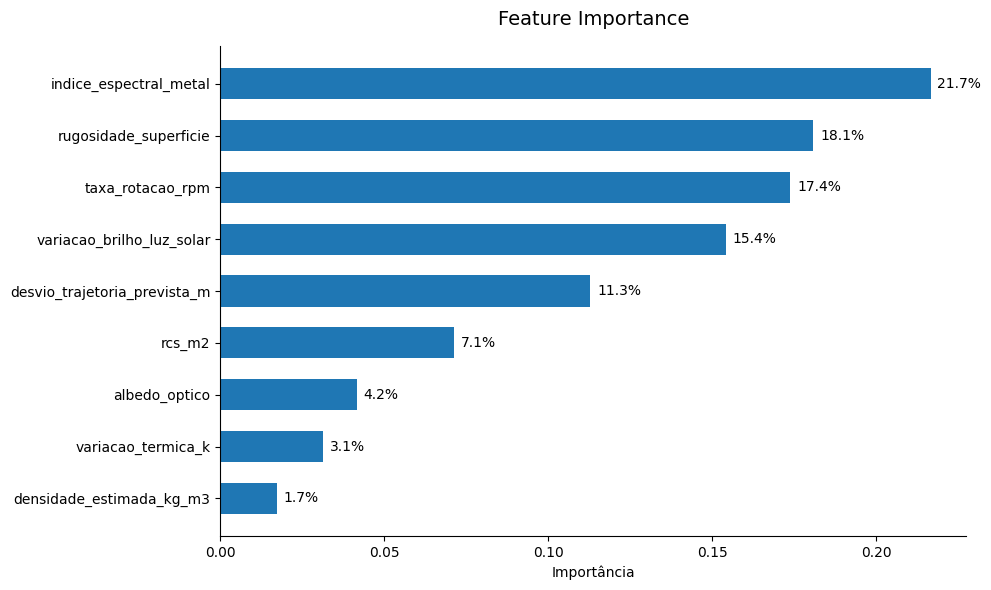

In [28]:
df_plot = importancias.sort_values(by='Importância', ascending=True).tail(9)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['Feature'], df_plot['Importância'], color='#1f77b4', height=0.6)

for bar in bars:
    width = bar.get_width()
    porcentagem = width * 100 
    ax.text(
        width + 0.002,          
        bar.get_y() + bar.get_height() / 2,
        f'{porcentagem:.1f}%',       
        ha='left',
        va='center',
        fontsize=10
    )

ax.set_title('Feature Importance', fontsize=14, pad=15)
ax.set_xlabel('Importância')
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## SHAP

Utilizando SHAP para verificar como o modelo toma decisões

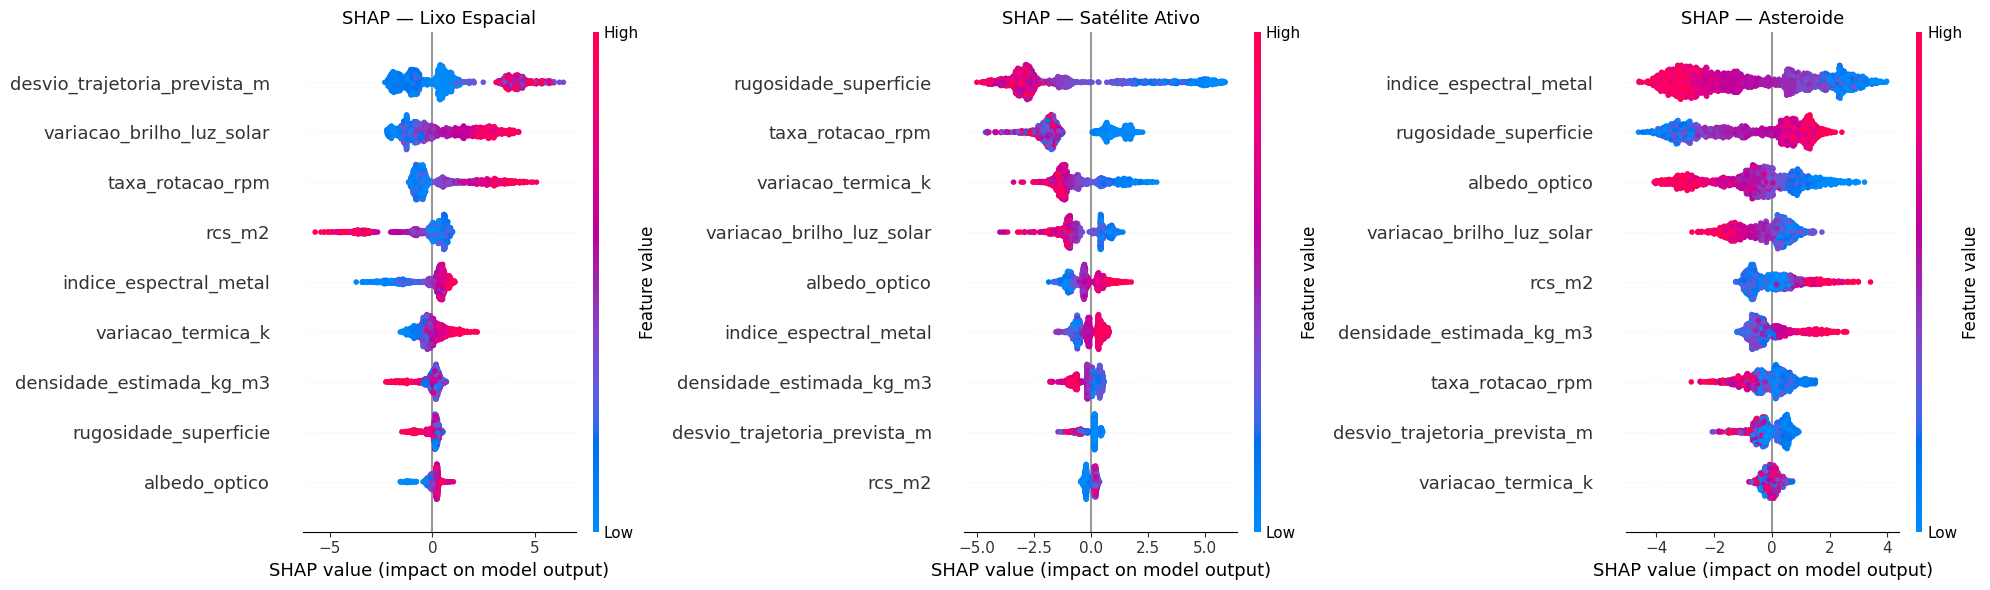

In [29]:
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(xtest2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
nomes_classes = ["Lixo Espacial", "Satélite Ativo", "Asteroide"]

for i, nome in enumerate(nomes_classes):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values[:, :, i],
        xtest2,
        show=False,
        plot_size=None
    )
    axes[i].set_title(f"SHAP — {nome}", fontsize=13)

plt.tight_layout()
plt.show()

# Conclusão comparativa

O modelo MLP e o modelo XGBoost, o modelo que melhor performa no problema relacionado à classificação de objetos espaciais com o intuito de melhorar e diminuir o tempo de tomada de decisões, é o modelo XGBoost. 

O dataset possui outliers intencionais de falha de sensores, fazendo com que o XGBoost, por ser baseado em árvores, seja naturalmente resistente a valores extremos. O MLP é mais sensível, o que pode gerar classificações instáveis exatamente nos casos mais críticos (casos que envolvem leituras anômalas são frequentemente os que exigem atenção imediata).

Portanto, optamos por seguir utilizando o modelo XGBoost para nossa solução, devido à sua maior acurácia, estabilidade e rapidez.

Salvando modelo vencedor com joblib...

In [30]:
joblib.dump(modelo_xgb, '../models/modelo_xgb.joblib')

['../models/modelo_xgb.joblib']